In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/palm-oil'):
    for filename in filenames:
        print(filename)
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as dfput when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved dfside of the current session

val.csv
/kaggle/input/palm-oil/val.csv
train.csv
/kaggle/input/palm-oil/train.csv
test.csv
/kaggle/input/palm-oil/test.csv


In [2]:
import pandas as pd

# Replace with your Kaggle dataset path
base_path = '/kaggle/input/palm-oil/'

# Load all three
train = pd.read_csv(base_path + 'train.csv')
val = pd.read_csv(base_path + 'val.csv')
test = pd.read_csv(base_path + 'test.csv')

# Check shape before combining
print(f"Train shape: {train.shape}")
print(f"Val shape:   {val.shape}")
print(f"Test shape:  {test.shape}")

# Combine all
df = pd.concat([train, val, test], axis=0, ignore_index=True)

# Verify combined result
print(f"\nCombined dataset shape: {df.shape}")
df.head()


Train shape: (5163, 43)
Val shape:   (1107, 43)
Test shape:  (1107, 43)

Combined dataset shape: (7377, 43)


,date,spot_close,fut_close,volume,next_day_pred,next_month_pred,ffb_price,oer,production,spot_ret,...,hr_ols_5,hr_ols_20,hr_ols_60,volume_z,dayofweek,month,sin_doy,cos_doy,is_month_end,hedge_ratio_target
0,2005-06-30 21:00:00,1709.57,1412.0,2508.00,1374.0,1419.750000,42.833021,19.68,1253581.0,0.0,...,0.000000e+00,0.000000e+00,1.406044e-12,-0.856670,3,6,0.027950,-0.999609,1,0.000000e+00
1,2005-07-01 21:00:00,1709.57,1418.0,2800.75,1372.0,1419.458333,42.833021,19.68,1253581.0,0.0,...,1.607946e-11,-1.460604e-12,1.455220e-12,-0.499385,4,7,0.010751,-0.999942,0,-1.460604e-12
2,2005-07-02 21:00:00,1709.57,1424.0,3093.50,1370.0,1419.166667,42.833021,19.68,1253581.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,-0.201187,5,7,-0.006451,-0.999979,0,0.000000e+00
3,2005-07-03 21:00:00,1709.57,1430.0,3386.25,1368.0,1418.875000,42.833021,19.68,1253581.0,0.0,...,7.386759e-12,2.306110e-12,0.000000e+00,0.066200,6,7,-0.023651,-0.999720,0,2.306110e-12
4,2005-07-04 21:00:00,1709.57,1436.0,3679.00,1366.0,1418.583333,42.833021,19.68,1253581.0,0.0,...,6.467518e-12,3.671032e-12,-1.325111e-12,0.394189,0,7,-0.040844,-0.999166,0,3.671032e-12


===== Dataset Overview =====
Shape: (7377, 43)

First 5 rows:


,date,spot_close,fut_close,volume,next_day_pred,next_month_pred,ffb_price,oer,production,spot_ret,fut_ret,log_ret_spot,log_ret_fut,basis,basis_pct,spot_ma_5,fut_ma_5,spot_std_5,fut_std_5,basis_mean_5,basis_std_5,spot_ma_20,fut_ma_20,spot_std_20,fut_std_20,basis_mean_20,basis_std_20,spot_ma_60,fut_ma_60,spot_std_60,fut_std_60,basis_mean_60,basis_std_60,hr_ols_5,hr_ols_20,hr_ols_60,volume_z,dayofweek,month,sin_doy,cos_doy,is_month_end,hedge_ratio_target
0,2005-06-30 21:00:00,1709.57,1412.0,2508.00,1374.0,1419.750000,42.833021,19.68,1253581.0,0.0,0.002841,0.0,0.002837,-297.57,-0.174061,1709.57,1413.55,0.0,5.821297,-296.02,5.821297,1709.57,1410.8875,0.0,19.992511,-298.6825,19.992511,1709.57,1403.241667,0.0,18.352075,-306.328333,18.352075,0.000000e+00,0.000000e+00,1.406044e-12,-0.856670,3,6,0.027950,-0.999609,1,0.000000e+00
1,2005-07-01 21:00:00,1709.57,1418.0,2800.75,1372.0,1419.458333,42.833021,19.68,1253581.0,0.0,0.004249,0.0,0.004240,-291.57,-0.170552,1709.57,1413.80,0.0,6.016644,-295.77,6.016644,1709.57,1412.9625,0.0,18.319223,-296.6075,18.319223,1709.57,1402.991667,0.0,18.039327,-306.578333,18.039327,1.607946e-11,-1.460604e-12,1.455220e-12,-0.499385,4,7,0.010751,-0.999942,0,-1.460604e-12
2,2005-07-02 21:00:00,1709.57,1424.0,3093.50,1370.0,1419.166667,42.833021,19.68,1253581.0,0.0,0.004231,0.0,0.004222,-285.57,-0.167042,1709.57,1416.80,0.0,6.723095,-292.77,6.723095,1709.57,1415.2500,0.0,16.525101,-294.3200,16.525101,1709.57,1403.208333,0.0,18.214364,-306.361667,18.214364,0.000000e+00,0.000000e+00,0.000000e+00,-0.201187,5,7,-0.006451,-0.999979,0,0.000000e+00
3,2005-07-03 21:00:00,1709.57,1430.0,3386.25,1368.0,1418.875000,42.833021,19.68,1253581.0,0.0,0.004213,0.0,0.004205,-279.57,-0.163532,1709.57,1418.40,0.0,8.876936,-291.17,8.876936,1709.57,1417.7500,0.0,14.579185,-291.8200,14.579185,1709.57,1403.491667,0.0,18.499254,-306.078333,18.499254,7.386759e-12,2.306110e-12,0.000000e+00,0.066200,6,7,-0.023651,-0.999720,0,2.306110e-12
4,2005-07-04 21:00:00,1709.57,1436.0,3679.00,1366.0,1418.583333,42.833021,19.68,1253581.0,0.0,0.004196,0.0,0.004187,-273.57,-0.160023,1709.57,1424.00,0.0,9.486833,-285.57,9.486833,1709.57,1420.7000,0.0,11.555245,-288.8700,11.555245,1709.57,1403.825000,0.0,18.904213,-305.745000,18.904213,6.467518e-12,3.671032e-12,-1.325111e-12,0.394189,0,7,-0.040844,-0.999166,0,3.671032e-12



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377 entries, 0 to 7376
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                7377 non-null   object 
 1   spot_close          7377 non-null   float64
 2   fut_close           7377 non-null   float64
 3   volume              7377 non-null   float64
 4   next_day_pred       7377 non-null   float64
 5   next_month_pred     7377 non-null   float64
 6   ffb_price           7377 non-null   float64
 7   oer                 7377 non-null   float64
 8   production          7377 non-null   float64
 9   spot_ret            7377 non-null   float64
 10  fut_ret             7377 non-null   float64
 11  log_ret_spot        7377 non-null   float64
 12  log_ret_fut         7377 non-null   float64
 13  basis               7377 non-null   float64
 14  basis_pct           7377 non-null   float64
 15  spot_ma_5           7377 non-null   float64
 16 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,7377,7377,2005-06-30 21:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spot_close,7377.0,NaN,NaN,NaN,3250.919008,1000.68108,1709.57,2590.324194,2974.176774,3888.942903,7529.08
fut_close,7377.0,NaN,NaN,NaN,2884.355903,947.11376,1344.0,2264.0,2600.5,3521.0,7104.0
volume,7377.0,NaN,NaN,NaN,18576.59184,10262.923414,0.0,10374.5,18601.0,25498.0,74439.0
next_day_pred,7377.0,NaN,NaN,NaN,2917.226679,916.550999,1357.0,2320.0,2643.904762,3527.666667,7074.0
next_month_pred,7377.0,NaN,NaN,NaN,2939.004031,903.093758,1377.0,2335.0,2678.05,3500.0,6482.0
ffb_price,7377.0,NaN,NaN,NaN,42.833021,0.185239,41.488246,42.833021,42.833021,42.833021,45.099444
oer,7377.0,NaN,NaN,NaN,19.66719,0.12243,19.05,19.68,19.68,19.68,20.01
production,7377.0,NaN,NaN,NaN,1281581.299173,91906.098936,1137462.0,1253581.0,1253581.0,1253581.0,1771621.0
spot_ret,7377.0,NaN,NaN,NaN,0.000133,0.002027,-0.007036,-0.000878,0.000108,0.001402,0.005005



===== Missing Values =====
No missing values ✅

===== Duplicate Rows =====
Duplicate rows: 0

===== Data Types =====
float64    39
int64       3
object      1
Name: count, dtype: int64
date                   object
spot_close            float64
fut_close             float64
volume                float64
next_day_pred         float64
next_month_pred       float64
ffb_price             float64
oer                   float64
production            float64
spot_ret              float64
fut_ret               float64
log_ret_spot          float64
log_ret_fut           float64
basis                 float64
basis_pct             float64
spot_ma_5             float64
fut_ma_5              float64
spot_std_5            float64
fut_std_5             float64
basis_mean_5          float64
basis_std_5           float64
spot_ma_20            float64
fut_ma_20             float64
spot_std_20           float64
fut_std_20            float64
basis_mean_20         float64
basis_std_20          float64
spot

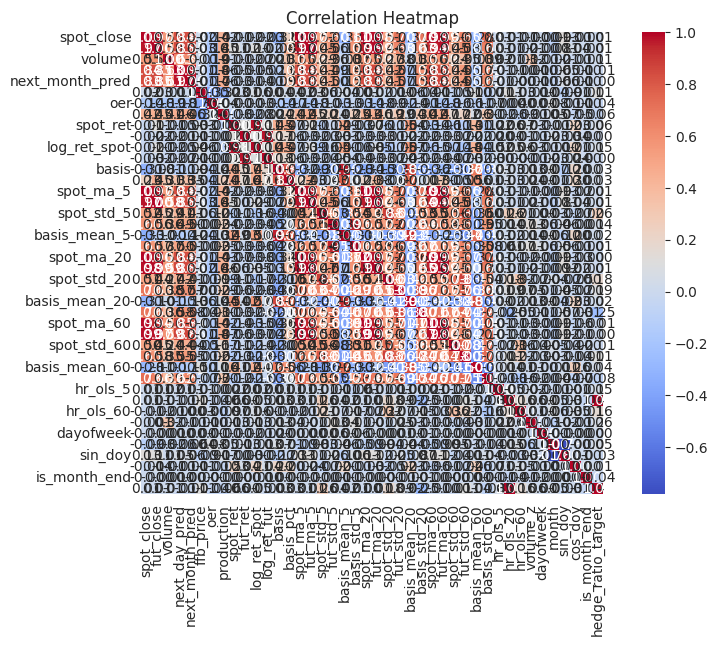


===== Numerical Feature Distributions =====


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_laydf'

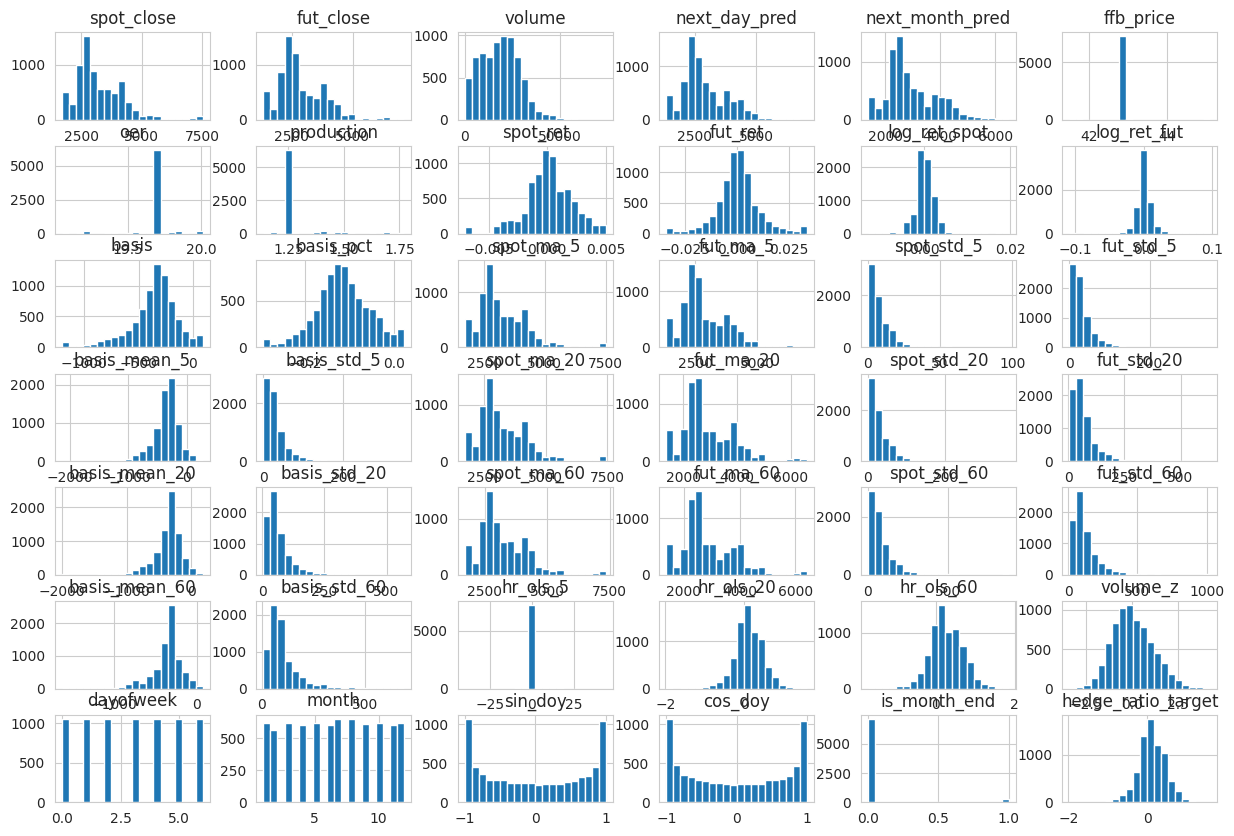

In [3]:
# ======================================================
# 📊 Basic Data Exploration Script (for Kaggle)
# ======================================================

# 1️⃣ Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')

# 3️⃣ Basic Overview
print("===== Dataset Overview =====")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nInfo:")
print(df.info())
print("\nSummary Statistics:")
display(df.describe(include='all').transpose())

# 4️⃣ Missing Values
print("\n===== Missing Values =====")
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values ✅")
else:
    display(missing)

# 5️⃣ Duplicates
print("\n===== Duplicate Rows =====")
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    print("You can remove them using: df = df.drop_duplicates()")

# 6️⃣ Data Types Summary
print("\n===== Data Types =====")
print(df.dtypes.value_counts())
print(df.dtypes)

# 7️⃣ Correlation (for numeric columns)
print("\n===== Correlation Matrix =====")
numeric_df = df.select_dtypes(include=[np.number])
if not numeric_df.empty:
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print("No numeric columns found.")

# 8️⃣ Target Variable (if applicable)
# Replace 'target' with your actual target column if you have one
# sns.countplot(x='target', data=df)
# plt.title('Target Variable Distribution')
# plt.show()

# 9️⃣ Numerical Feature Distributions
print("\n===== Numerical Feature Distributions =====")
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_laydf()
plt.show()

# 🔟 Categorical Feature Distributions
print("\n===== Categorical Feature Distributions =====")
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().nlargest(10).plot(kind='bar')
    plt.title(f'{col} - Top 10 Categories')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

print("\n✅ EDA Completed Successfully!")


In [ ]:
# ======================================================
# 📈 Financial Time-Series EDA for Hedging Dataset
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')

# ======================================================
# 1️⃣ Basic Overview
# ======================================================
print("===== Dataset Overview =====")
print(f"Shape: {df.shape}")
print("\nInfo:")
print(df.info())
print("\nSummary Statistics:")
display(df.describe().transpose())

# ======================================================
# 2️⃣ Missing & Duplicate Checks
# ======================================================
print("\n===== Missing Values =====")
missing = df.isnull().sum()
display(missing[missing > 0])

print("\n===== Duplicates =====")
print(f"Duplicate rows: {df.duplicated().sum()}")

# ======================================================
# 3️⃣ Datetime Handling
# ======================================================
# Explicitly convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date')
df.set_index('date', inplace=True)

print("\nDate range:", df.index.min(), "→", df.index.max())
print("Total days:", (df.index.max() - df.index.min()).days)

# ======================================================
# 4️⃣ Price Relationship Analysis
# ======================================================
plt.figure(figsize=(12,5))
plt.plot(df.index, df['spot_close'], label='Spot Price', lw=1.5)
plt.plot(df.index, df['fut_close'], label='Futures Price', lw=1.5, alpha=0.8)
plt.title('Spot vs Futures Prices Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df.index, df['basis'], color='purple', label='Basis (Spot - Futures)')
plt.axhline(0, color='black', ls='--')
plt.title('Basis Over Time')
plt.legend()
plt.show()

# ======================================================
# 5️⃣ Return Analysis
# ======================================================
plt.figure(figsize=(12,5))
plt.plot(df.index, df['spot_ret'], label='Spot Return')
plt.plot(df.index, df['fut_ret'], label='Futures Return', alpha=0.7)
plt.title('Spot vs Futures Returns')
plt.legend()
plt.show()

print("\nReturn Statistics:")
display(df[['spot_ret', 'fut_ret', 'log_ret_spot', 'log_ret_fut']].describe())

# ======================================================
# 6️⃣ Correlation Matrix (financial core)
# ======================================================
corr_cols = ['spot_close', 'fut_close', 'basis', 'spot_ret', 'fut_ret', 
              'hr_ols_5', 'hr_ols_20', 'hr_ols_60', 'volume']
corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Core Financial Variables')
plt.show()

# ======================================================
# 7️⃣ Hedge Ratio Dynamics
# ======================================================
plt.figure(figsize=(12,5))
plt.plot(df.index, df['hr_ols_5'], label='OLS 5-day')
plt.plot(df.index, df['hr_ols_20'], label='OLS 20-day')
plt.plot(df.index, df['hr_ols_60'], label='OLS 60-day')
plt.title('Hedge Ratio (OLS-based) Over Time')
plt.legend()
plt.show()

print("\nHedge Ratio Summary:")
display(df[['hr_ols_5','hr_ols_20','hr_ols_60']].describe())

# ======================================================
# 8️⃣ Volume and Volatility Behavior
# ======================================================
fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)
axes[0].plot(df.index, df['volume'], color='orange')
axes[0].set_title('Trading Volume Over Time')
axes[1].plot(df.index, df['spot_std_20'], label='Spot Std (20d)', color='teal')
axes[1].plot(df.index, df['fut_std_20'], label='Futures Std (20d)', color='gray')
axes[1].set_title('Rolling Volatility (20-day)')
axes[1].legend()
plt.tight_laydf()
plt.show()

# ======================================================
# 9️⃣ Predictive Target Correlations
# ======================================================
target_corr = df[['next_day_pred','next_month_pred','spot_close','fut_close','basis']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(target_corr, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Between Targets and Price Features')
plt.show()

# ======================================================
# 🔟 Seasonal Patterns
# ======================================================
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(x='month', y='basis', data=df, ax=ax[0])
ax[0].set_title('Monthly Basis Distribution')
sns.boxplot(x='dayofweek', y='spot_ret', data=df, ax=ax[1])
ax[1].set_title('Day-of-Week Return Pattern')
plt.show()

# ======================================================
# 11️⃣ Statistical Insights Summary
# ======================================================
print("\n===== Statistical Highlights =====")
print(f"Mean basis: {df['basis'].mean():.3f}")
print(f"Basis volatility (std): {df['basis'].std():.3f}")
print(f"Mean hedge ratio (20-day): {df['hr_ols_20'].mean():.3f}")
print(f"Spot vs Futures Return Corr: {df['spot_ret'].corr(df['fut_ret']):.3f}")
print(f"Spot vs Futures Price Corr:  {df['spot_close'].corr(df['fut_close']):.3f}")
print(f"Average daily volume: {df['volume'].mean():,.0f}")

print("\n✅ EDA & Financial Insights Extraction Complete")


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# Create lag features
df["spot_ret"] = df["spot_close"].pct_change()
df["fut_ret"] = df["fut_close"].pct_change()
df["basis"] = df["spot_close"] - df["fut_close"]

df["spot_ret"] = df["spot_close"].pct_change()
df["fut_ret"]  = df["fut_close"].pct_change()

for w in [5, 20, 60]:
    df[f"cov_{w}"]  = df["spot_ret"].rolling(w).cov(df["fut_ret"])
    df[f"varf_{w}"] = df["fut_ret"].rolling(w).var()
    df[f"corr_{w}"] = df["spot_ret"].rolling(w).corr(df["fut_ret"])
    df[f"ols_proxy_{w}"] = df[f"cov_{w}"] / (df[f"varf_{w}"] + 1e-12)

df["ols_proxy_diff_5_20"] = df["ols_proxy_5"] - df["ols_proxy_20"]
df["ols_proxy_diff_20_60"] = df["ols_proxy_20"] - df["ols_proxy_60"]


for lag in [1, 5, 10]:
    df[f'spot_ret_lag{lag}'] = df['spot_ret'].shift(lag)
    df[f'fut_ret_lag{lag}'] = df['fut_ret'].shift(lag)
    df[f'basis_lag{lag}'] = df['basis'].shift(lag)

df["vol_regime"] = (df["fut_ret"].rolling(20).std() > df["fut_ret"].rolling(60).std()).astype(int)

# Shift hedge ratio to be the "future" target
df["target_hr"] = df["hr_ols_20"].shift(-30)
df["hr_now"] = df["hr_ols_20"]
df["target_dhr"] = df["target_hr"] - df["hr_now"]
# df["target_hr"] = df["hr_ols_20"].shift(-30).rolling(10).mean()


# Drop NaN values from rolling + shift
# df = df.dropna(subset=["target_hr"])
df = df.dropna(subset=["target_dhr"])

print(df.columns)

# 'spot_close', 'fut_close', 'volume', 'next_day_pred',
#        'next_month_pred', 'ffb_price', 'oer', 'production', 'spot_ret',
#        'fut_ret', 'log_ret_spot', 'log_ret_fut', 'basis', 'basis_pct',
#        'spot_ma_5', 'fut_ma_5', 'spot_std_5', 'fut_std_5', 'basis_mean_5',
#        'basis_std_5', 'spot_ma_20', 'fut_ma_20', 'spot_std_20', 'fut_std_20',
#        'basis_mean_20', 'basis_std_20', 'spot_ma_60', 'fut_ma_60',
#        'spot_std_60', 'fut_std_60', 'basis_mean_60', 'basis_std_60',
#        'hr_ols_5', 'hr_ols_20', 'hr_ols_60', 'volume_z', 'dayofweek', 'month',
#        'sin_doy', 'cos_doy', 'is_month_end', 'hedge_ratio_target', 'target_hr',
#        'spot_ret_lag1', 'fut_ret_lag1', 'basis_lag1', 'spot_ret_lag5',
#        'fut_ret_lag5', 'basis_lag5', 'spot_ret_lag10', 'fut_ret_lag10',
#        'basis_lag10', 'corr_20', 'cov_20', 'var_fut_20', 'ols_proxy_20',
#        'hr_now', 'target_dhr', 'cov_5', 'varf_5', 'corr_5', 'ols_proxy_5',
#        'varf_20', 'cov_60', 'varf_60', 'corr_60', 'ols_proxy_60',
#        'target_dhr_smooth'

features = [
    # price and returns
    "spot_ret", "fut_ret", "log_ret_spot", "log_ret_fut",
    "basis", "basis_pct",

    # volatility and moving averages
    "spot_ma_5", "spot_ma_20", "fut_ma_5", "fut_ma_20",
    "spot_std_5", "spot_std_20", "fut_std_5", "fut_std_20",
    "basis_std_5", "basis_std_20",
    "spot_ret_lag5", "spot_ret_lag1", "spot_ret_lag10"
    , "fut_ret_lag5", "fut_ret_lag1", "fut_ret_lag10"
    , "basis_lag5", "basis_lag1", "basis_lag10",
    'cov_5', 'varf_5', 'corr_5', 'ols_proxy_5',
    'varf_20', 'cov_60', 'varf_60', 'corr_60', 'ols_proxy_60',
    'ols_proxy_diff_5_20', 'ols_proxy_diff_20_60',
    'vol_regime',

    # short-term memory (past hedge ratio signals)
    "hr_ols_5", "hr_ols_20", "hr_ols_60",

    # external and predictive features
    "next_day_pred", "next_month_pred",
    "production", "ffb_price", "oer",

    # liquidity & seasonality
    "volume_z", "dayofweek", "month", "sin_doy", "cos_doy", "is_month_end"
]


X = df[features]
# y = df["target_hr"]
y = df["target_dhr"]

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# Model training
model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.5,
    max_depth=6, 
    learning_rate=0.05, random_state=42, max_iter=500)
# model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# importances = pd.Series(model.feature_importances_, index=X.columns)
# importances.sort_values().plot(kind="barh", title="Feature Importance")
# plt.show()

# Compute realized HR 30 days later (ground truth)
hr_future = df["hr_ols_20"].shift(-30).iloc[-len(y_test):].values

# Assume we adjust current HR by predicted ΔHR
hr_adjusted = df["hr_ols_20"].iloc[-len(y_test):].values + y_pred

# Compute realized hedge PnL variance proxy
basis_ret = (df["spot_ret"] - df["fut_ret"]).iloc[-len(y_test):].values

# Portfolio return variance: lower = better hedge
var_original = (basis_ret ** 2).mean()
var_adjusted = ((basis_ret - hr_adjusted * df["fut_ret"].iloc[-len(y_test):].values) ** 2).mean()

print("Variance reduction: ", 1 - (var_adjusted / var_original))